<a href="https://colab.research.google.com/github/vijayaditya123/Review/blob/main/Review_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IoT Symmetry Dataset:**


Question 1: Anomaly Detection

Question 2: Predict Smoke Levels

Question 3: Cluster Devices by Sensor Patterns

Question 4: Factors Influencing Motion Detection

Question 5: Predict Temperature based on Environment


For Dataset :[Link](https://docs.google.com/spreadsheets/d/1yaP5ik3tov0PeT3C-saDp7q1sjhKk2Lz0kDCtkPktAc/edit?usp=sharing)

In [ ]:
"Question 1: Anomaly Detection"

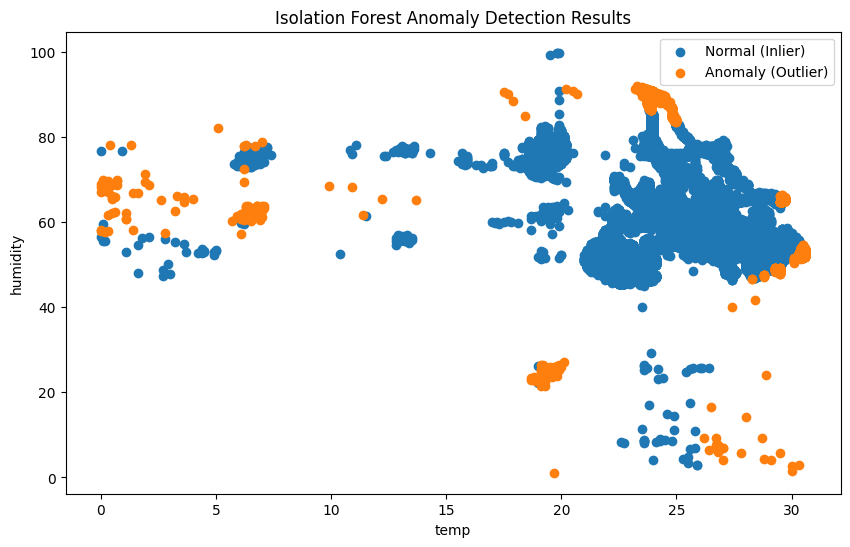

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


df = pd.read_csv("/content/iot_telemetry_data - iot_telemetry_data.csv")

smoke = df


feature1 = 'temp'
feature2 = 'humidity'

X = smoke[[feature1, feature2]].dropna()


iso_forest = IsolationForest(contamination=0.01, random_state=42)
predictions = iso_forest.fit_predict(X)

plot_data = X.copy()
plot_data['anomaly'] = predictions


plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data[plot_data['anomaly'] == 1][feature1],
    plot_data[plot_data['anomaly'] == 1][feature2],
    label='Normal (Inlier)'
)

plt.scatter(
    plot_data[plot_data['anomaly'] == -1][feature1],
    plot_data[plot_data['anomaly'] == -1][feature2],
    label='Anomaly (Outlier)'
)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Isolation Forest Anomaly Detection Results')
plt.legend()
plt.show()


In [ ]:
"Question 2: Predict Smoke Levels"

In [12]:
import pandas as pd
smoke = pd.read_csv("/content/iot_telemetry_data - iot_telemetry_data.csv")
smoke["ts"]=pd.to_datetime(smoke["ts"])

In [13]:
smoke.head()

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1970-01-01 00:00:01.590,b8:27:eb:bf:9d:51,0.004956,51.000000,False,0.007651,False,0.020411,22.700000
1,1970-01-01 00:00:01.590,00:0f:00:70:91:0a,0.002840,76.000000,False,0.005114,False,0.013275,19.700001
2,1970-01-01 00:00:01.590,b8:27:eb:bf:9d:51,0.004976,50.900000,False,0.007673,False,0.020475,22.600000
3,1970-01-01 00:00:01.590,1c:bf:ce:15:ec:4d,0.004403,76.800003,True,0.007023,False,0.018628,27.000000
4,1970-01-01 00:00:01.590,b8:27:eb:bf:9d:51,0.004967,50.900000,False,0.007664,False,0.020448,22.600000


In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
smoke["device"]=le.fit_transform(smoke["device"])
smoke["light"]=le.fit_transform(smoke["light"])
smoke["motion"]=le.fit_transform(smoke["motion"])

In [15]:
smoke.head()

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1970-01-01 00:00:01.590,2,0.004956,51.000000,0,0.007651,0,0.020411,22.700000
1,1970-01-01 00:00:01.590,0,0.002840,76.000000,0,0.005114,0,0.013275,19.700001
2,1970-01-01 00:00:01.590,2,0.004976,50.900000,0,0.007673,0,0.020475,22.600000
3,1970-01-01 00:00:01.590,1,0.004403,76.800003,1,0.007023,0,0.018628,27.000000
4,1970-01-01 00:00:01.590,2,0.004967,50.900000,0,0.007664,0,0.020448,22.600000


In [16]:
columns=["device","co","humidity","light","temp"]
X = smoke[columns]
y= smoke["smoke"]

In [17]:
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [18]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [19]:
y_pred=model.predict(X_test)

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
r2_score=r2_score(y_test, y_pred)
print(f"R2 Score: {r2_score}")

Mean Absolute Error: 0.00011008041330239097
R2 Score: 0.9970744711263713


In [21]:
"Question 3: Cluster Devices by Sensor Patterns"

'Question 3: Cluster Devices by Sensor Patterns'

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
smoke["device"]=le.fit_transform(smoke["device"])
smoke["light"]=le.fit_transform(smoke["light"])
smoke["motion"]=le.fit_transform(smoke["motion"])


In [23]:
columns=["smoke","co","humidity","light","temp"]
X = smoke[columns]
y= smoke["device"]
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
knn_classifier.fit(X_train, y_train)
y_pred = knn_classifier.predict(X_test)


In [25]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9999629798733912


In [ ]:
"Question 4: Factors Influencing Motion Detection"

In [27]:
smoke = pd.read_csv("/content/iot_telemetry_data - iot_telemetry_data.csv")

In [28]:
smoke["ts"]=pd.to_datetime(smoke["ts"]).astype('int64')
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
smoke["device"]=le.fit_transform(smoke["device"])
smoke["light"]=le.fit_transform(smoke["light"])
smoke["motion"]=le.fit_transform(smoke["motion"])

In [29]:
columns=["ts","device","co","humidity","light","temp"]
X = smoke[columns]
y= smoke["motion"]

In [30]:
smoke.head()

,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1590000000,2,0.004956,51.000000,0,0.007651,0,0.020411,22.700000
1,1590000000,0,0.002840,76.000000,0,0.005114,0,0.013275,19.700001
2,1590000000,2,0.004976,50.900000,0,0.007673,0,0.020475,22.600000
3,1590000000,1,0.004403,76.800003,1,0.007023,0,0.018628,27.000000
4,1590000000,2,0.004967,50.900000,0,0.007664,0,0.020448,22.600000


In [31]:
from sklearn.linear_model import LogisticRegression
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [32]:
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9989387563705467


In [33]:
"Question 5: Predict Temperature based on Environment"

'Question 5: Predict Temperature based on Environment'

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
smoke["device"]=le.fit_transform(smoke["device"])
smoke["light"]=le.fit_transform(smoke["light"])
smoke["motion"]=le.fit_transform(smoke["motion"])

In [36]:
columns=["humidity","light","motion","lpg","co"]
X = smoke[columns]
y= smoke["temp"]
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.tree import DecisionTreeRegressor
model= DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)

In [38]:
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score
r2_score=r2_score(y_test,y_pred)
r2_score

0.9027271315307358

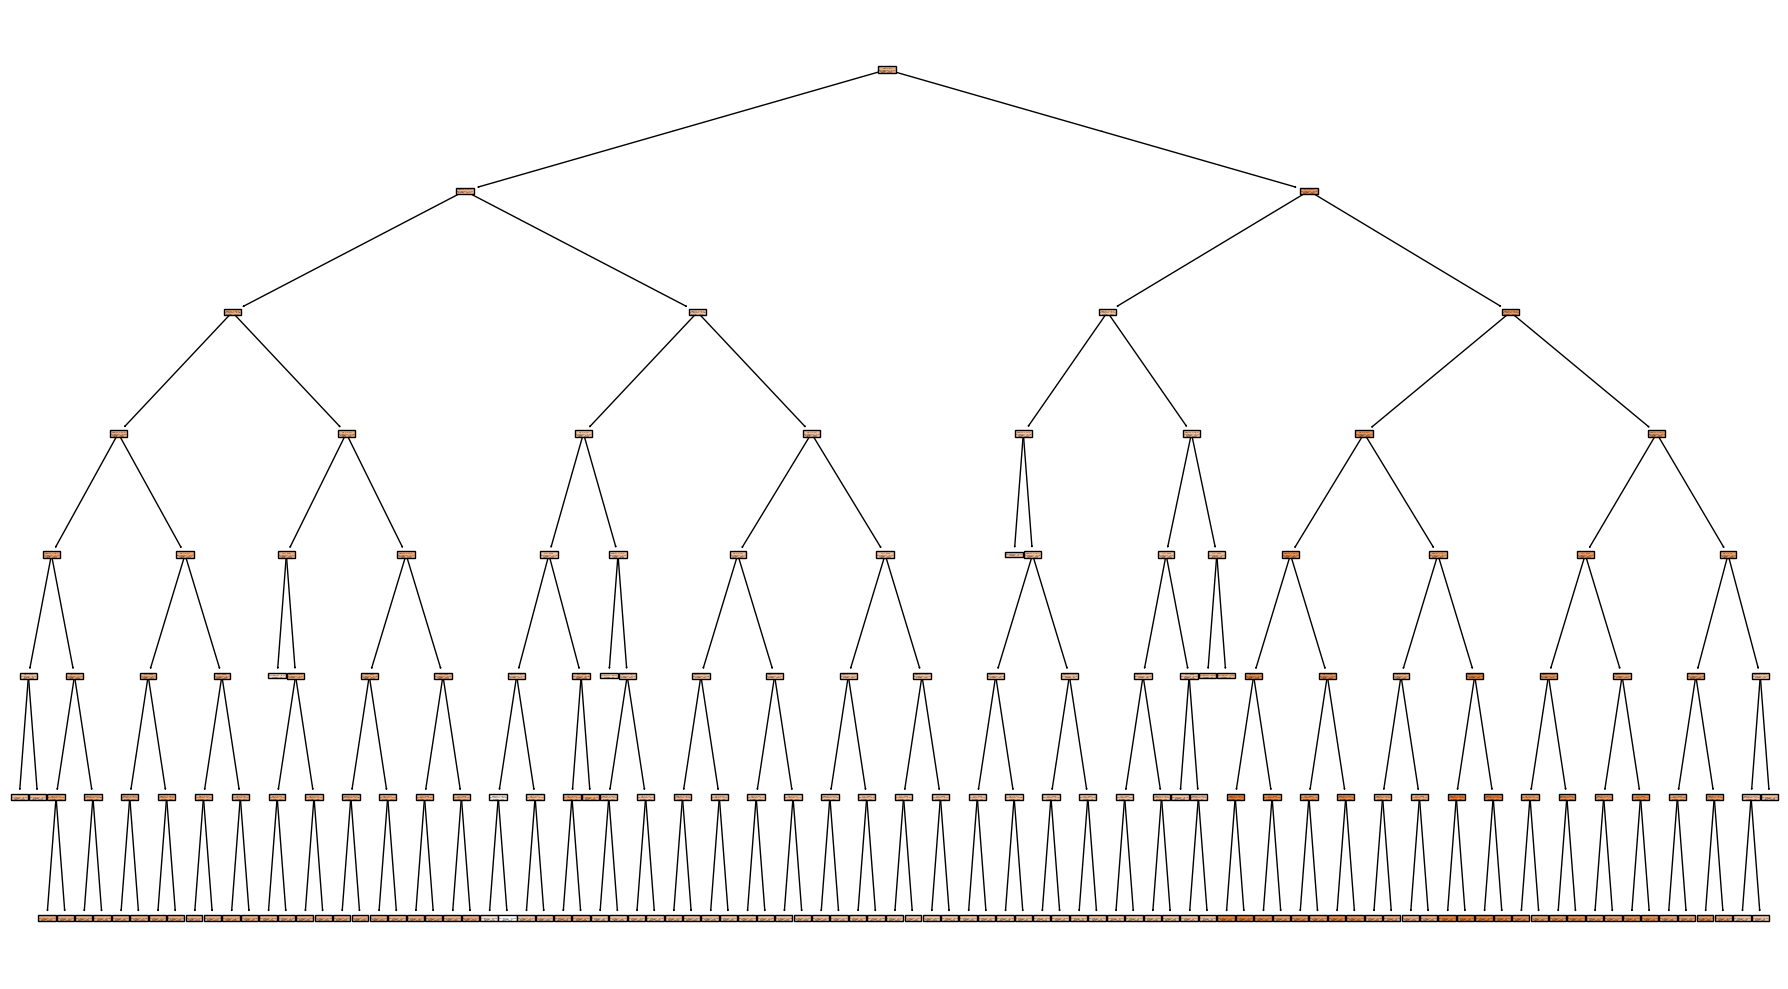

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

In [40]:
from sklearn.tree import DecisionTreeRegressor
model= DecisionTreeRegressor(max_depth=4, min_samples_leaf=16)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score
r2_score=r2_score(y_test,y_pred)
r2_score


0.8420196243770861

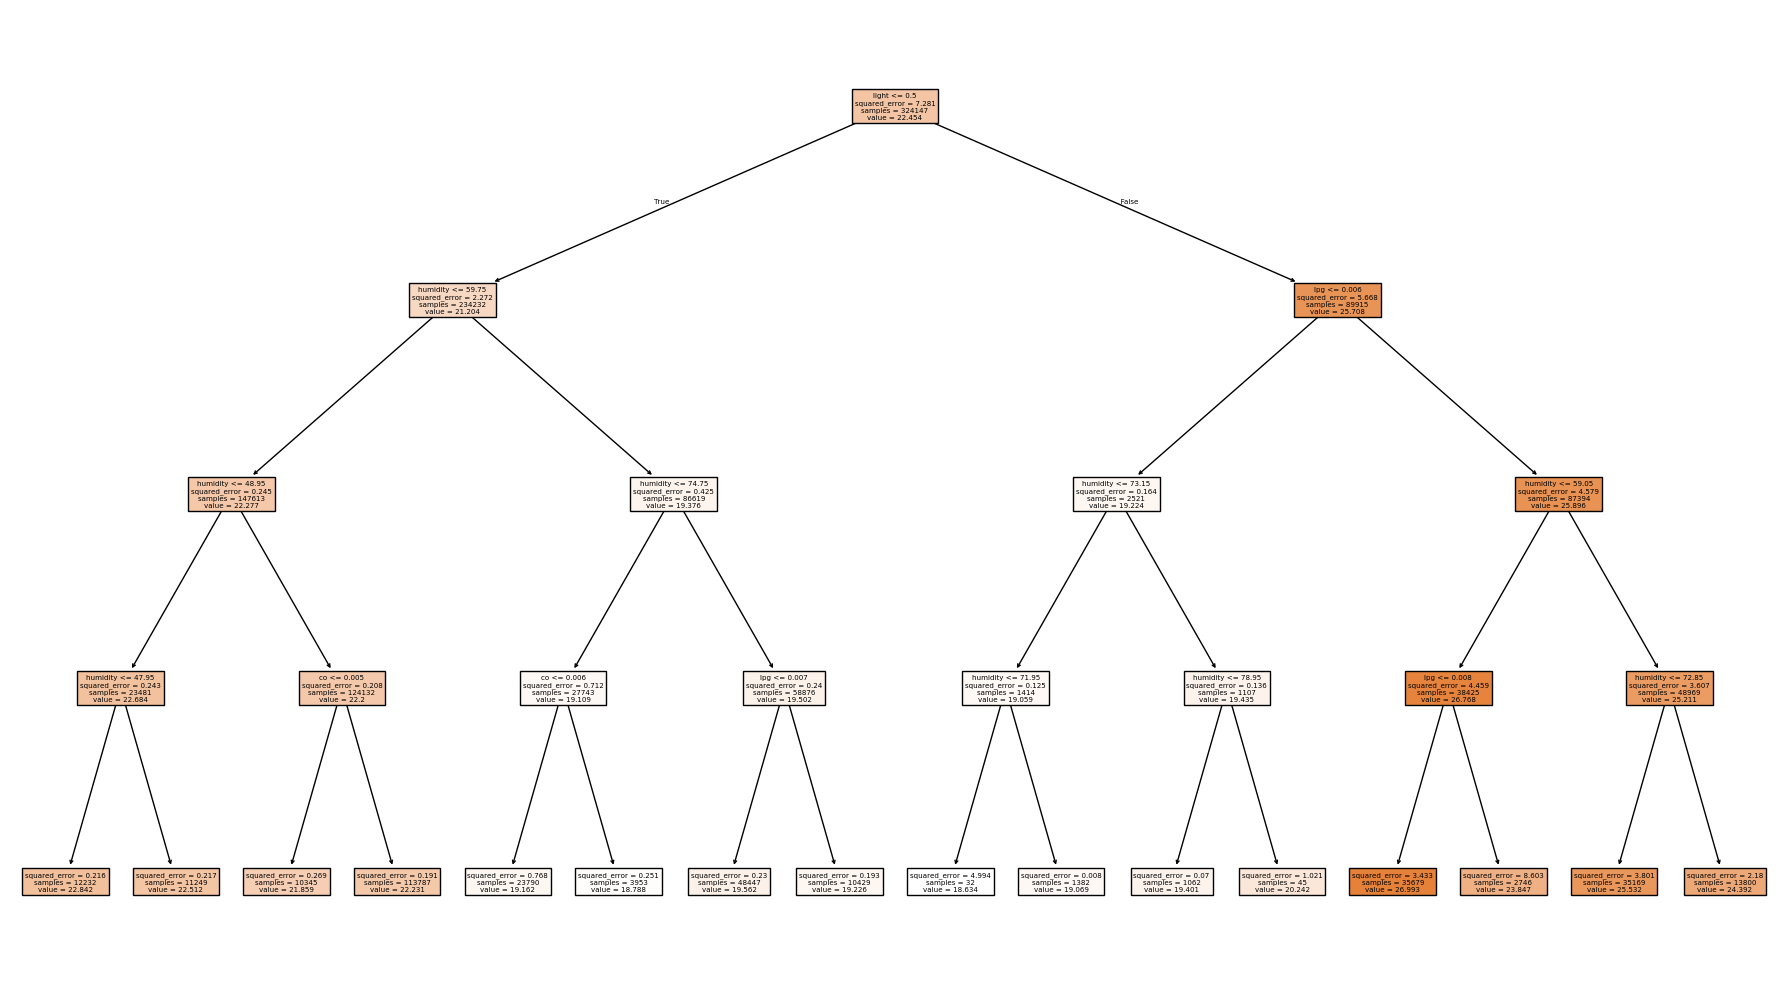

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()